# Spectrum pipeline — benchmark validation

Reproduce the gamma-ray and antiproton spectra for the hypercharge (vector) portal at the **Fig. 4 benchmark of [arXiv:1912.08821](https://arxiv.org/abs/1912.08821)**:

- $m_X = 76$ GeV, $m_Y = 60$ GeV
- Gamma-ray $E^2 dN/dE$ peak target: **1.4 – 4.0 GeV**
- Antiproton $E^2 dN/dE$ peak target: **6.2 – 12.6 GeV**

Run from `cosmo_env`.  The Pythia cache under `GCE/channel_spectra/` makes repeat runs near-instant; deleting a file forces its regeneration.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
while ROOT.name and not (ROOT / 'hidden_sector_DM').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from hidden_sector_DM.HiddenSectorDM import VectorPortal, BaryonPortal
from GCE import DATA_DIR, FIGS_DIR
from GCE.pythia_runner import PythiaRunner
from GCE.spectrum import (GEVM2_TO_CM3S, cascade_flux, cascade_spectrum,
                          default_ebins)

PAPER = DATA_DIR / 'spectra_1912.08821'   # digitised Fig. 4 curves
plt.style.use(ROOT / 'notebooks' / 'mine.mplstyle')
plt.rcParams['axes.axisbelow'] = False


In [2]:
mX, mY = 76.0, 60.0
N_EVENTS = 100_000

model = VectorPortal(mX=mX, mY=mY, gX=2, gY=3, alphaX=3.8e-3,
                     include_antiparticlesX=True, include_antiparticlesY=False)
svV=model.sigmav_XX_to_YY_swave()*GEVM2_TO_CM3S
print(svV)
ebins = np.logspace(np.log10(1e-3 * mX), np.log10(mX), 81)
runner = PythiaRunner(seed=12345)

print('Branching ratios:')
for ch, br in sorted(model.branching_ratios_to_SM().items(), key=lambda kv: -kv[1]):
    if br > 0:
        print(f'  {ch:8s}  {br:.3f}')

4.473966214620945e-26
Branching ratios:
  uu        0.186
  cc        0.186
  ee        0.106
  mumu      0.106
  tautau    0.106
  dd        0.092
  ss        0.092
  bb        0.091
  nunu_e    0.012
  nunu_mu   0.012
  nunu_tau  0.012


In [3]:
E_g, dNdE_g = cascade_spectrum(model, ebins, n_events=N_EVENTS, runner=runner,
                             species='gamma', verbose=True)
print()
E_p, dNdE_p = cascade_spectrum(model, ebins, n_events=N_EVENTS, runner=runner,
                             species='pbar', verbose=True)

  ee       cached, skipping (ee_mX76_mY60_N100000_s12345.npz)
  [gamma] ee       BR=0.106  n_per_decay=0.55
  mumu     cached, skipping (mumu_mX76_mY60_N100000_s12345.npz)
  [gamma] mumu     BR=0.106  n_per_decay=0.29
  tautau   cached, skipping (tautau_mX76_mY60_N100000_s12345.npz)
  [gamma] tautau   BR=0.106  n_per_decay=2.32
  uu       cached, skipping (uu_mX76_mY60_N100000_s12345.npz)
  [gamma] uu       BR=0.186  n_per_decay=15.05
  cc       cached, skipping (cc_mX76_mY60_N100000_s12345.npz)
  [gamma] cc       BR=0.186  n_per_decay=16.09
  dd       cached, skipping (dd_mX76_mY60_N100000_s12345.npz)
  [gamma] dd       BR=0.092  n_per_decay=15.09
  ss       cached, skipping (ss_mX76_mY60_N100000_s12345.npz)
  [gamma] ss       BR=0.092  n_per_decay=14.04
  bb       cached, skipping (bb_mX76_mY60_N100000_s12345.npz)
  [gamma] bb       BR=0.091  n_per_decay=18.57

  tautau   cached, skipping (tautau_mX76_mY60_N100000_s12345.npz)
  [pbar] tautau   BR=0.106  n_per_decay=0.00
  uu       ca

In [4]:
peak_g = E_g[np.argmax(E_g * E_g * dNdE_g)]
peak_p = E_p[np.argmax(E_p * E_p * dNdE_p)]
tot_g = float(np.sum(dNdE_g * np.diff(ebins)))
tot_p = float(np.sum(dNdE_p * np.diff(ebins)))

print(f'gamma : peak = {peak_g:.3g} GeV   (target 1.4 - 4.0)   total = {tot_g:.2f}/ann')
print(f'pbar  : peak = {peak_p:.3g} GeV   (target 6.2 - 12.6)  total = {tot_p:.2f}/ann')

assert 1.4 <= peak_g <= 4.3,  f'gamma peak {peak_g} GeV outside target'
assert 6.1 <= peak_p <= 12.6, f'pbar peak {peak_p} GeV outside target'
print('\nBoth peaks satisfy the Fig. 4 targets.')

gamma : peak = 4.21 GeV   (target 1.4 - 4.0)   total = 20.97/ann
pbar  : peak = 7.71 GeV   (target 6.2 - 12.6)  total = 1.07/ann

Both peaks satisfy the Fig. 4 targets.


In [5]:
model2 = BaryonPortal(mX=60, mY=30, gX=2, gY=3, alphaX=1e-2,
                     include_antiparticlesX=True, include_antiparticlesY=False)
ebins2 = np.logspace(np.log10(1e-3 * 60), np.log10(60), 81)
runner2 = PythiaRunner(seed=12346)
E_g2, dNdE_g2 = cascade_spectrum(model2, ebins2, n_events=N_EVENTS, runner=runner2,
                             species='gamma', verbose=True)
print()
E_p2, dNdE_p2 = cascade_spectrum(model2, ebins2, n_events=N_EVENTS, runner=runner2,
                             species='pbar', verbose=True)

  uu       cached, skipping (uu_mX60_mY30_N100000_s12346.npz)
  [gamma] uu       BR=0.200  n_per_decay=11.46
  dd       cached, skipping (dd_mX60_mY30_N100000_s12346.npz)
  [gamma] dd       BR=0.200  n_per_decay=11.52
  ss       cached, skipping (ss_mX60_mY30_N100000_s12346.npz)
  [gamma] ss       BR=0.200  n_per_decay=10.42
  cc       cached, skipping (cc_mX60_mY30_N100000_s12346.npz)
  [gamma] cc       BR=0.200  n_per_decay=12.42
  bb       cached, skipping (bb_mX60_mY30_N100000_s12346.npz)
  [gamma] bb       BR=0.200  n_per_decay=14.91

  uu       cached, skipping (uu_mX60_mY30_N100000_s12346.npz)
  [pbar] uu       BR=0.200  n_per_decay=0.65
  dd       cached, skipping (dd_mX60_mY30_N100000_s12346.npz)
  [pbar] dd       BR=0.200  n_per_decay=0.65
  ss       cached, skipping (ss_mX60_mY30_N100000_s12346.npz)
  [pbar] ss       BR=0.200  n_per_decay=0.60
  cc       cached, skipping (cc_mX60_mY30_N100000_s12346.npz)
  [pbar] cc       BR=0.200  n_per_decay=0.46
  bb       cached, skippin

In [6]:
y0=np.loadtxt(PAPER / "E2dNdE_gamma_vP_mX76_mY60.txt",skiprows=1)
y1=np.loadtxt(PAPER / "E2dNdE_antiproton_vP_mX76_mY60.txt",skiprows=1)
y2=np.loadtxt(PAPER / "E2dNdE_gamma_bP_mX60_mY30.txt",skiprows=1)
y3=np.loadtxt(PAPER / "E2dNdE_antiproton_bP_mX60_mY30.txt",skiprows=1)

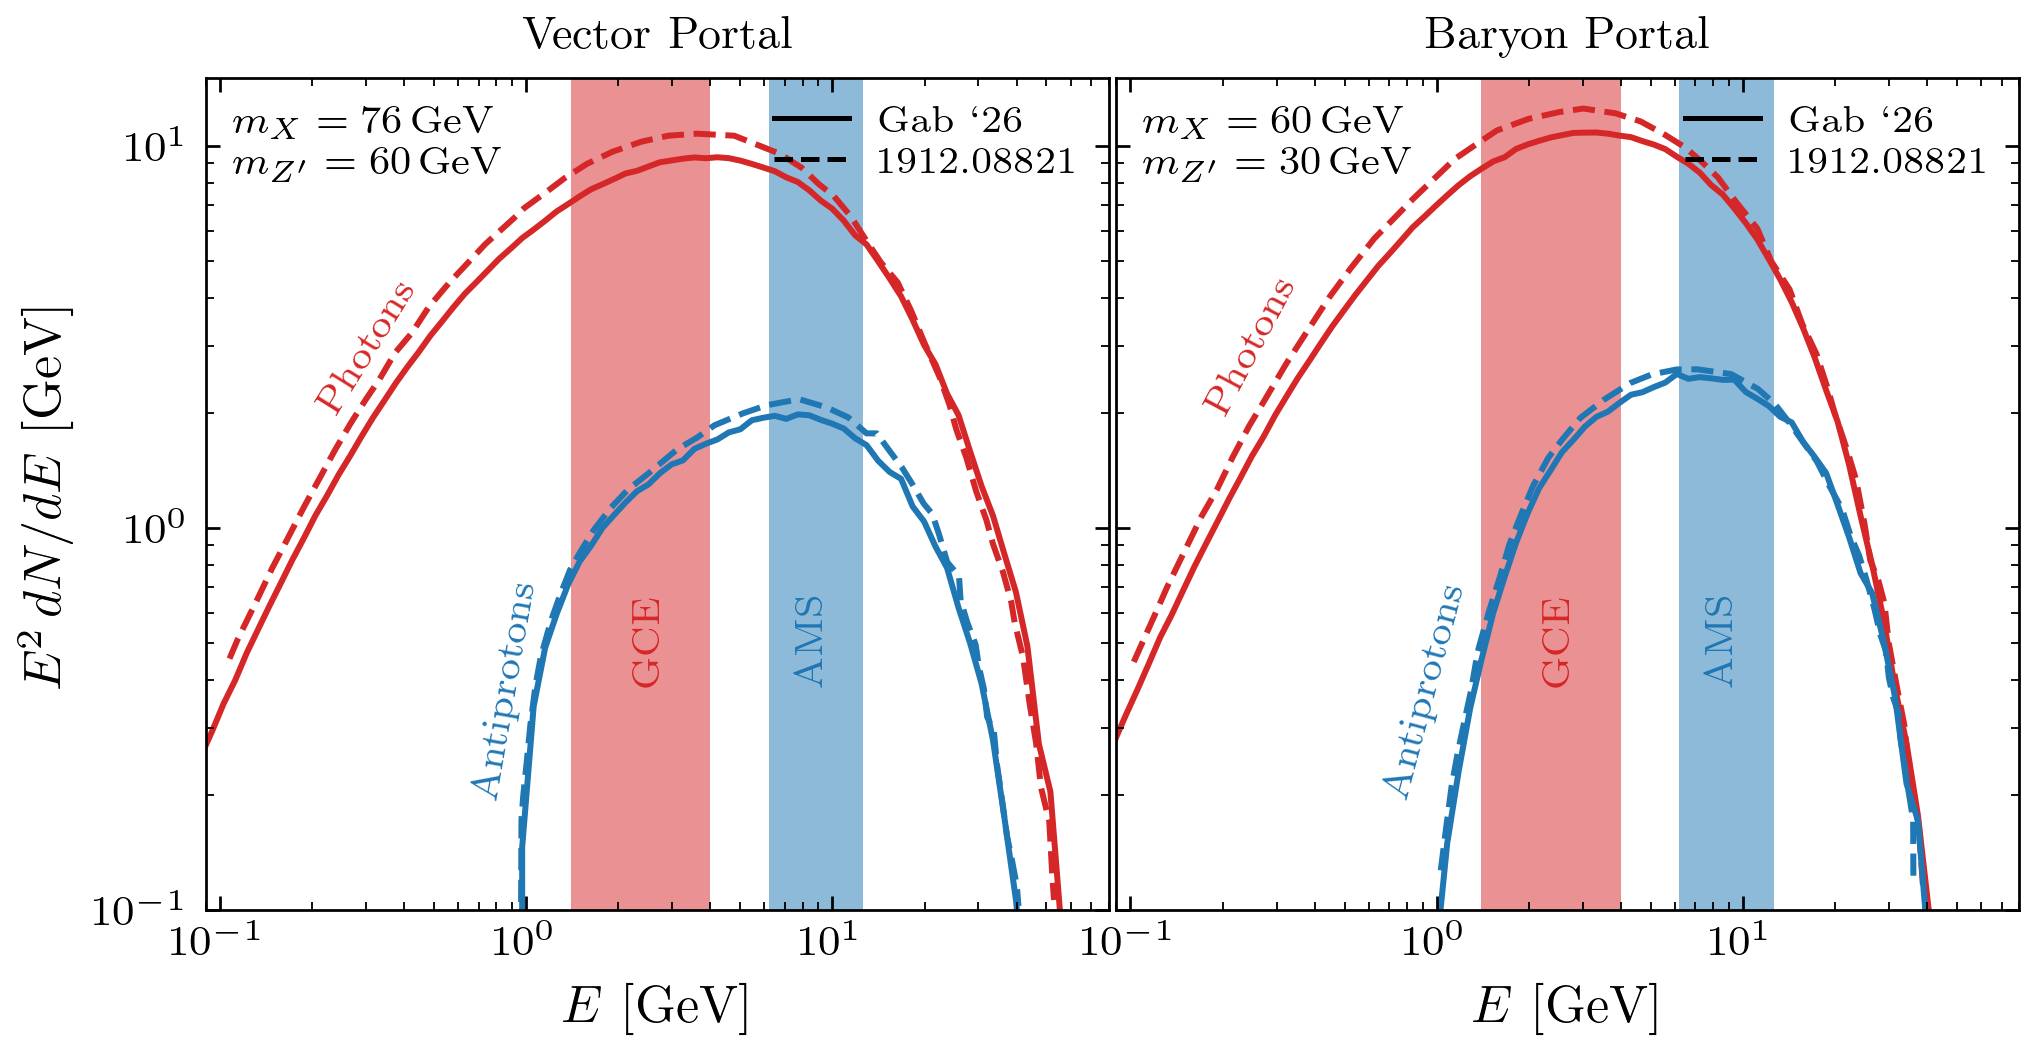

In [7]:
fig1=plt.figure(figsize=(6.5, 3))
#fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(23,40,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:20])
ax2 = fig1.add_subplot(gs1[:,20:])
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.axvspan(1.4, 4.0, alpha=0.5, color='tab:red',lw=0)
ax1.plot(E_g, E_g * E_g * dNdE_g, lw=1.2,c='tab:red')
ax1.plot(y0[:,0],y0[:,1],lw=1.2,ls='--',c='tab:red')
ax1.plot(np.NaN,np.NaN,c='k',lw=1,label='Gab `26')
ax1.plot(np.NaN,np.NaN,c='k',lw=1, ls='--',label='1912.08821')
ax1.set_xlabel(r'$E$ [GeV]')
ax1.set_ylabel(r'$E^2\, dN/dE$  [GeV]')
ax1.text(2e-1,2,'Photons',rotation=58, fontdict={'fontsize':8,'family':'serif','color':'tab:red'})
ax1.text(6.5e-1,0.2,'Antiprotons',rotation=80, fontdict={'fontsize':8,'family':'serif','color':'tab:blue'})
ax1.text(1.1e-1,8.5,r'$m_{X}=76\,{\rm GeV}$'+'\n'+r'$m_{Z^\prime}=60\,{\rm GeV}$',fontdict={'fontsize':8,'family':'serif','color':'k'},
         ha='left')
ax1.set_title("Vector Portal", fontsize=9)
ax1.text(2.2,0.4,"GCE",rotation=90,fontdict={'fontsize':8,'family':'serif','color':'tab:red'})
ax1.text(7.5,0.4,"AMS",rotation=90,fontdict={'fontsize':8,'family':'serif','color':'tab:blue'})
ax1.legend(loc=1)
ax1.axvspan(6.2, 12.6, color='tab:blue', alpha=0.5, lw=0)
ax1.plot(E_p, E_p * E_p * dNdE_p, lw=1.2, color='tab:blue')
ax1.plot(y1[:,0],y1[:,1],lw=1.2,ls='--',c='tab:blue')
ax1.set_ylim(1e-1,15)
ax1.set_xlim(9e-2,80)


ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.axvspan(1.4, 4.0, alpha=0.5, color='tab:red',lw=0)
ax2.plot(E_g2, E_g2 * E_g2 * dNdE_g2, lw=1.2,c='tab:red')
ax2.plot(y2[:,0],y2[:,1],lw=1.2,ls='--',c='tab:red')
ax2.plot(np.NaN,np.NaN,c='k',lw=1,label='Gab `26')
ax2.plot(np.NaN,np.NaN,c='k',lw=1, ls='--',label='1912.08821')
ax2.set_xlabel(r'$E$ [GeV]')
ax2.text(1.7e-1,2,'Photons',rotation=62, fontdict={'fontsize':8,'family':'serif','color':'tab:red'})
ax2.text(6.5e-1,0.2,'Antiprotons',rotation=75, fontdict={'fontsize':8,'family':'serif','color':'tab:blue'})
ax2.text(1.1e-1,8.5,r'$m_{X}=60\,{\rm GeV}$'+'\n'+r'$m_{Z^\prime}=30\,{\rm GeV}$',fontdict={'fontsize':8,'family':'serif','color':'k'},
         ha='left')
ax2.set_title("Baryon Portal", fontsize=9)
ax2.text(2.2,0.4,"GCE",rotation=90,fontdict={'fontsize':8,'family':'serif','color':'tab:red'})
ax2.text(7.5,0.4,"AMS",rotation=90,fontdict={'fontsize':8,'family':'serif','color':'tab:blue'})
ax2.legend(loc=1)
ax2.axvspan(6.2, 12.6, color='tab:blue', alpha=0.5, lw=0)
ax2.plot(E_p2, E_p2 * E_p2 * dNdE_p2, lw=1.2, color='tab:blue')
ax2.plot(y3[:,0],y3[:,1],lw=1.2,ls='--',c='tab:blue')
ax2.set_ylim(1e-1,15)
ax2.set_xlim(9e-2,80)
ax2.set_yticklabels([])
plt.savefig(FIGS_DIR / "GCE_spectra_comparison_with_201912.08821.png")
plt.show()
plt.close()